In [7]:
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,accuracy_score
import numpy as np
import ssl
import pandas as pd
from PIL import Image

## train

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
data_dir = "images_3"
train_dir = os.path.join(data_dir, "train_images")
val_dir = os.path.join(data_dir, "val_images")
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=transform['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=transform['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [10]:
ssl._create_default_https_context = ssl._create_unverified_context

In [11]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
num_epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_losses.append(train_loss / len(train_loader.dataset))
    train_accs.append(correct / total)

    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_losses.append(val_loss / len(val_loader.dataset))
    val_accs.append(correct / total)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, "
          f"Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

Epoch 1/20, Train Loss: 0.6989, Val Loss: 0.4464, Train Acc: 0.8045, Val Acc: 0.8901
Epoch 2/20, Train Loss: 0.6201, Val Loss: 0.4742, Train Acc: 0.8330, Val Acc: 0.8771
Epoch 3/20, Train Loss: 0.6026, Val Loss: 0.3881, Train Acc: 0.8372, Val Acc: 0.9021
Epoch 4/20, Train Loss: 0.5928, Val Loss: 0.4676, Train Acc: 0.8410, Val Acc: 0.8791
Epoch 5/20, Train Loss: 0.5904, Val Loss: 0.4038, Train Acc: 0.8407, Val Acc: 0.8951
Epoch 6/20, Train Loss: 0.5843, Val Loss: 0.4190, Train Acc: 0.8413, Val Acc: 0.9001
Epoch 7/20, Train Loss: 0.5796, Val Loss: 0.3951, Train Acc: 0.8426, Val Acc: 0.9011
Epoch 8/20, Train Loss: 0.5808, Val Loss: 0.3997, Train Acc: 0.8420, Val Acc: 0.9001
Epoch 9/20, Train Loss: 0.5749, Val Loss: 0.3919, Train Acc: 0.8438, Val Acc: 0.8991
Epoch 10/20, Train Loss: 0.5720, Val Loss: 0.3700, Train Acc: 0.8459, Val Acc: 0.9041
Epoch 11/20, Train Loss: 0.5791, Val Loss: 0.3762, Train Acc: 0.8437, Val Acc: 0.9031
Epoch 12/20, Train Loss: 0.5751, Val Loss: 0.3662, Train Acc: 0

In [13]:
torch.save(model.state_dict(), "mobilenet_finetuned.pth")

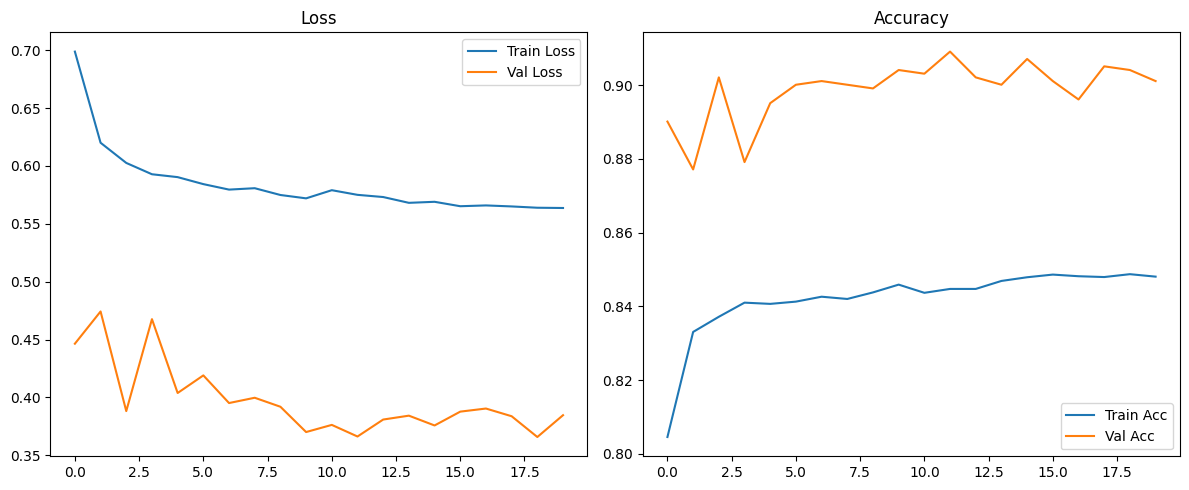

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.tight_layout()
plt.show()


## đánh giá

In [2]:
data_dir = "data/images_3"
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
num_classes = len(test_dataset.classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)
model.load_state_dict(torch.load("temp/models/mobilenet_finetuned.pth",  map_location=device))

label_map = {'BENIGN': 0, 'Group1' : 1, 'Group2': 2, "Syn": 3 }

In [3]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


In [4]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 90.25%


In [5]:
class_names = test_dataset.classes
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.89       250
           1       0.93      0.87      0.90       250
           2       0.89      0.89      0.89       251
           3       0.94      0.91      0.92       244

    accuracy                           0.90       995
   macro avg       0.90      0.90      0.90       995
weighted avg       0.90      0.90      0.90       995



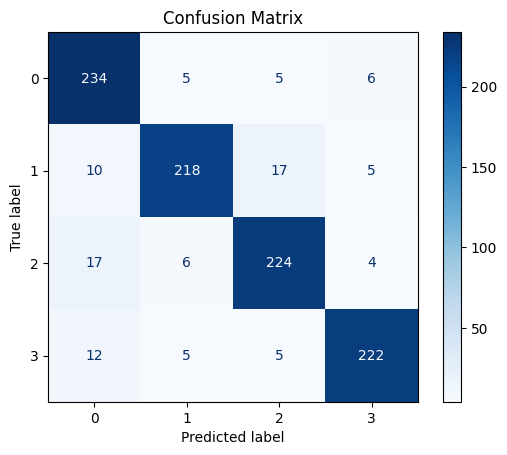

In [6]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

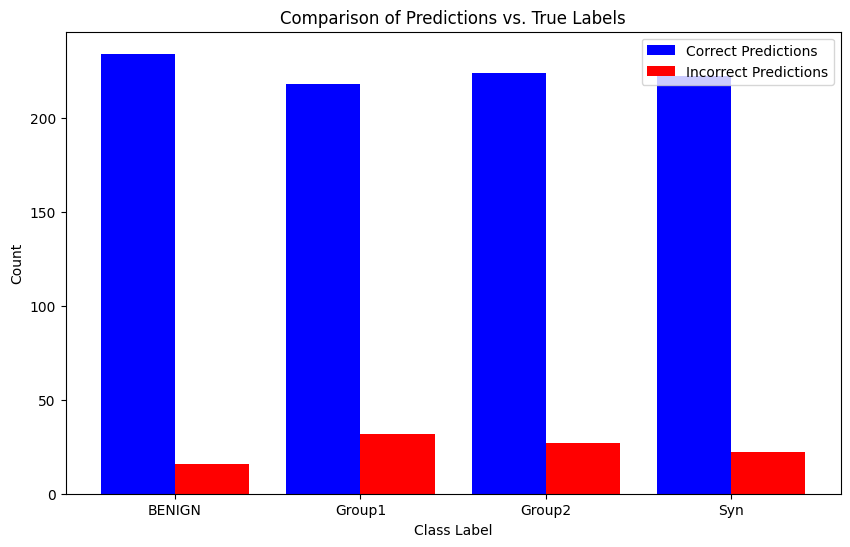

In [8]:
# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": all_labels, "Predicted Label": all_preds})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [9]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


# Test individual images
def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [10]:
labels_list = list(label_map.keys())

print(labels_list)
test_data_paths = list(map(lambda x: x, test_dataset.imgs))

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

# thống kê chi tiết tên nhãn dự đoán
for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data_paths:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)



['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 234, 'Syn': 6, 'Group1': 5, 'Group2': 5}
Label: Group1 {'BENIGN': 10, 'Group1': 218, 'Group2': 17, 'Syn': 5}
Label: Group2 {'BENIGN': 17, 'Group1': 6, 'Group2': 224, 'Syn': 4}
Label: Syn {'BENIGN': 12, 'Syn': 222, 'Group1': 5, 'Group2': 5}
